# Basin-level precipitation climatology table (1995–2014)

This notebook produces table of basin-scale precipitation climatology for Jordan's 12 hydrological basins, derived from station observations aggregated to the basin level over the reference period **1995–2014**. The output establishes a basin-specific climatic baseline that anchors subsequent model-evaluation, ensemble-comparison, and projection analyses.

Three columns of climatological information are presented per basin:
1. **Annual mean precipitation** (mm yr⁻¹) — calendar-year totals averaged across stations within each basin and over the 20-year period.
2. **Wet-season mean precipitation** (October–March; mm season⁻¹).
3. **Dry-season mean precipitation** (April–September; mm season⁻¹).

An **aridity classification** based on annual precipitation is appended, following the precipitation-threshold scheme commonly used in dryland climatology (e.g., Middleton & Thomas, 1997; UNEP World Atlas of Desertification):
- **Hyper-arid**: P < 100 mm yr⁻¹
- **Arid**: 100 ≤ P < 200 mm yr⁻¹
- **Semi-arid**: 200 ≤ P < 400 mm yr⁻¹
- **Dry sub-humid**: 400 ≤ P < 600 mm yr⁻¹

The number of stations contributing to each basin's aggregate is reported transparently in a dedicated column, since station coverage is not uniform across basins.

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

# --- Path configuration -----------------------------------------------------
INPUT_PATH  = Path(r"C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\basin_annual_mean_1995_2014.xlsx")
OUTPUT_DIR  = INPUT_PATH.parent
OUTPUT_XLSX = OUTPUT_DIR / "Table_Basin_Climatology_1995_2014.xlsx"
OUTPUT_PNG  = OUTPUT_DIR / "Table_Basin_Climatology_1995_2014.png"
OUTPUT_CSV  = OUTPUT_DIR / "Table_Basin_Climatology_1995_2014.csv"

print(f"Reading: {INPUT_PATH}")
print(f"Outputs will be written to: {OUTPUT_DIR}")

Reading: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\basin_annual_mean_1995_2014.xlsx
Outputs will be written to: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments


## 2. Read basin-level summary

In [2]:
# The 'Basin Summary' sheet contains pre-aggregated mean / min / max / std for each basin
# across annual, wet (Oct-Mar) and dry (Apr-Sep) windows. Header occupies the first three rows;
# we read with a multi-row header and then flatten.
raw = pd.read_excel(INPUT_PATH, sheet_name="Basin Summary", header=[1, 2])
raw.columns = [
    " | ".join([str(a).strip() for a in col if str(a) != "nan"]).strip(" |")
    for col in raw.columns.to_flat_index()
]
raw.head()

,Unnamed: 0_level_0 | Basin,Unnamed: 1_level_0 | N Stn\n(Total),Unnamed: 2_level_0 | N Stn\n(Data),ANNUAL (mm/yr) | Mean,ANNUAL (mm/yr) | Min,ANNUAL (mm/yr) | Max,ANNUAL (mm/yr) | Std,WET SEASON Oct-Mar (mm/season) | Mean,WET SEASON Oct-Mar (mm/season) | Min,WET SEASON Oct-Mar (mm/season) | Max,WET SEASON Oct-Mar (mm/season) | Std,DRY SEASON Apr-Sep (mm/season) | Mean,DRY SEASON Apr-Sep (mm/season) | Min,DRY SEASON Apr-Sep (mm/season) | Max,DRY SEASON Apr-Sep (mm/season) | Std
0,N.R.S.W,4,4,445.0,346.7,584.6,100.0,436.4,339.4,577.6,100.6,25.4,18.9,30.4,4.8
1,YARMOUK (JORDAN),5,5,303.4,156.0,378.8,97.4,295.6,152.0,369.5,94.4,18.2,7.6,24.2,7.3
2,JORDAN VALLY (JORDAN),3,3,276.6,245.8,322.7,40.7,273.7,244.3,318.1,39.1,17.0,14.7,19.4,2.4
3,AMMAN ZARQA (JORDAN),6,6,222.2,92.9,438.4,144.9,220.5,92.6,438.2,144.4,10.3,4.7,19.8,6.7
4,S.R.S.W,4,4,349.2,217.3,507.7,120.4,345.5,213.8,504.6,120.5,17.7,13.2,26.1,5.8


In [3]:
# Inspect column names so we can pull exactly what we need
for c in raw.columns:
    print(repr(c))

'Unnamed: 0_level_0 | Basin'
'Unnamed: 1_level_0 | N Stn\n(Total)'
'Unnamed: 2_level_0 | N Stn\n(Data)'
'ANNUAL  (mm/yr) | Mean'
'ANNUAL  (mm/yr) | Min'
'ANNUAL  (mm/yr) | Max'
'ANNUAL  (mm/yr) | Std'
'WET SEASON  Oct-Mar  (mm/season) | Mean'
'WET SEASON  Oct-Mar  (mm/season) | Min'
'WET SEASON  Oct-Mar  (mm/season) | Max'
'WET SEASON  Oct-Mar  (mm/season) | Std'
'DRY SEASON  Apr-Sep  (mm/season) | Mean'
'DRY SEASON  Apr-Sep  (mm/season) | Min'
'DRY SEASON  Apr-Sep  (mm/season) | Max'
'DRY SEASON  Apr-Sep  (mm/season) | Std'


## 3. Build the climatology table

In [4]:
# Pick the columns we need by matching on substrings (robust to whitespace/newlines)
def find_col(df, must_contain):
    for c in df.columns:
        if all(s.lower() in c.lower() for s in must_contain):
            return c
    raise KeyError(f"No column matches all of {must_contain}")

col_basin    = find_col(raw, ["basin"])
col_nstn     = find_col(raw, ["n stn", "data"])
col_ann_mean = find_col(raw, ["annual", "mean"])
col_ann_std  = find_col(raw, ["annual", "std"])
col_wet_mean = find_col(raw, ["wet season", "mean"])
col_wet_std  = find_col(raw, ["wet season", "std"])
col_dry_mean = find_col(raw, ["dry season", "mean"])
col_dry_std  = find_col(raw, ["dry season", "std"])

tab = pd.DataFrame({
    "Basin":              raw[col_basin],
    "N stations":         raw[col_nstn].astype(int),
    "Annual mean (mm/yr)":      raw[col_ann_mean].astype(float).round(1),
    "Annual std (mm/yr)":       raw[col_ann_std].astype(float).round(1),
    "Wet-season mean (mm)":     raw[col_wet_mean].astype(float).round(1),
    "Wet-season std (mm)":      raw[col_wet_std].astype(float).round(1),
    "Dry-season mean (mm)":     raw[col_dry_mean].astype(float).round(1),
    "Dry-season std (mm)":      raw[col_dry_std].astype(float).round(1),
})

# Keep basin labels clean
tab["Basin"] = (
    tab["Basin"].astype(str)
       .str.replace(" (JORDAN)", "", regex=False)
       .str.strip()
)
tab

,Basin,N stations,Annual mean (mm/yr),Annual std (mm/yr),Wet-season mean (mm),Wet-season std (mm),Dry-season mean (mm),Dry-season std (mm)
0,N.R.S.W,4,445.0,100.0,436.4,100.6,25.4,4.8
1,YARMOUK,5,303.4,97.4,295.6,94.4,18.2,7.3
2,JORDAN VALLY,3,276.6,40.7,273.7,39.1,17.0,2.4
3,AMMAN ZARQA,6,222.2,144.9,220.5,144.4,10.3,6.7
4,S.R.S.W,4,349.2,120.4,345.5,120.5,17.7,5.8
5,D.S.R.S.W,7,254.8,42.1,252.2,44.9,15.2,1.2
6,MUJIB,6,172.2,71.9,168.5,70.7,10.9,4.7
7,W. ARABA NORTH,3,185.4,51.2,185.2,55.9,12.0,1.5
8,HASA,1,162.7,NaN,158.5,NaN,12.7,NaN
9,AZRAQ,4,52.2,21.0,51.2,20.9,4.0,1.1


## 4. Aridity classification

Annual precipitation thresholds applied:
- Hyper-arid: P < 100 mm yr⁻¹
- Arid:       100 ≤ P < 200 mm yr⁻¹
- Semi-arid:  200 ≤ P < 400 mm yr⁻¹
- Dry sub-humid: 400 ≤ P < 600 mm yr⁻¹

In [5]:
def classify(p):
    if p < 100:
        return "Hyper-arid"
    elif p < 200:
        return "Arid"
    elif p < 400:
        return "Semi-arid"
    elif p < 600:
        return "Dry sub-humid"
    else:
        return "Humid"

tab["Aridity class"] = tab["Annual mean (mm/yr)"].apply(classify)

# Sort from wettest to driest — useful for the table presentation
tab = tab.sort_values("Annual mean (mm/yr)", ascending=False).reset_index(drop=True)
tab

,Basin,N stations,Annual mean (mm/yr),Annual std (mm/yr),Wet-season mean (mm),Wet-season std (mm),Dry-season mean (mm),Dry-season std (mm),Aridity class
0,N.R.S.W,4,445.0,100.0,436.4,100.6,25.4,4.8,Dry sub-humid
1,S.R.S.W,4,349.2,120.4,345.5,120.5,17.7,5.8,Semi-arid
2,YARMOUK,5,303.4,97.4,295.6,94.4,18.2,7.3,Semi-arid
3,JORDAN VALLY,3,276.6,40.7,273.7,39.1,17.0,2.4,Semi-arid
4,D.S.R.S.W,7,254.8,42.1,252.2,44.9,15.2,1.2,Semi-arid
5,AMMAN ZARQA,6,222.2,144.9,220.5,144.4,10.3,6.7,Semi-arid
6,W. ARABA NORTH,3,185.4,51.2,185.2,55.9,12.0,1.5,Arid
7,MUJIB,6,172.2,71.9,168.5,70.7,10.9,4.7,Arid
8,HASA,1,162.7,NaN,158.5,NaN,12.7,NaN,Arid
9,JAFER,5,77.0,28.8,77.0,30.1,5.5,0.6,Hyper-arid


## 5. Save outputs

We export the table in three forms:
- **Excel (.xlsx)** — for inclusion in supplementary material or further analysis.
- **CSV (.csv)** — universal interchange.
- **PNG (.png)** — a publication-style rendered table for direct insertion as a figure.

In [6]:
# Excel + CSV
tab.to_excel(OUTPUT_XLSX, index=False)
tab.to_csv(OUTPUT_CSV, index=False)
print("Wrote:", OUTPUT_XLSX)
print("Wrote:", OUTPUT_CSV)

Wrote: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\Table_Basin_Climatology_1995_2014.xlsx
Wrote: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\Table_Basin_Climatology_1995_2014.csv


In [7]:
# Compose mean ± std cells for the rendered table
def fmt_ms(mean, std):
    if pd.isna(std):
        return f"{mean:.1f}  (1 stn)"
    return f"{mean:.1f} \u00b1 {std:.1f}"

render = pd.DataFrame({
    "Basin":          tab["Basin"],
    "N stations":     tab["N stations"].astype(int),
    "Annual\n(mm yr$^{-1}$)":    [fmt_ms(m, s) for m, s in zip(tab["Annual mean (mm/yr)"], tab["Annual std (mm/yr)"])],
    "Wet (Oct–Mar)\n(mm season$^{-1}$)":  [fmt_ms(m, s) for m, s in zip(tab["Wet-season mean (mm)"], tab["Wet-season std (mm)"])],
    "Dry (Apr–Sep)\n(mm season$^{-1}$)":  [fmt_ms(m, s) for m, s in zip(tab["Dry-season mean (mm)"], tab["Dry-season std (mm)"])],
    "Aridity class": tab["Aridity class"],
})
render

,Basin,N stations,Annual\n(mm yr$^{-1}$),Wet (Oct–Mar)\n(mm season$^{-1}$),Dry (Apr–Sep)\n(mm season$^{-1}$),Aridity class
0,N.R.S.W,4,445.0 ± 100.0,436.4 ± 100.6,25.4 ± 4.8,Dry sub-humid
1,S.R.S.W,4,349.2 ± 120.4,345.5 ± 120.5,17.7 ± 5.8,Semi-arid
2,YARMOUK,5,303.4 ± 97.4,295.6 ± 94.4,18.2 ± 7.3,Semi-arid
3,JORDAN VALLY,3,276.6 ± 40.7,273.7 ± 39.1,17.0 ± 2.4,Semi-arid
4,D.S.R.S.W,7,254.8 ± 42.1,252.2 ± 44.9,15.2 ± 1.2,Semi-arid
5,AMMAN ZARQA,6,222.2 ± 144.9,220.5 ± 144.4,10.3 ± 6.7,Semi-arid
6,W. ARABA NORTH,3,185.4 ± 51.2,185.2 ± 55.9,12.0 ± 1.5,Arid
7,MUJIB,6,172.2 ± 71.9,168.5 ± 70.7,10.9 ± 4.7,Arid
8,HASA,1,162.7 (1 stn),158.5 (1 stn),12.7 (1 stn),Arid
9,JAFER,5,77.0 ± 28.8,77.0 ± 30.1,5.5 ± 0.6,Hyper-arid


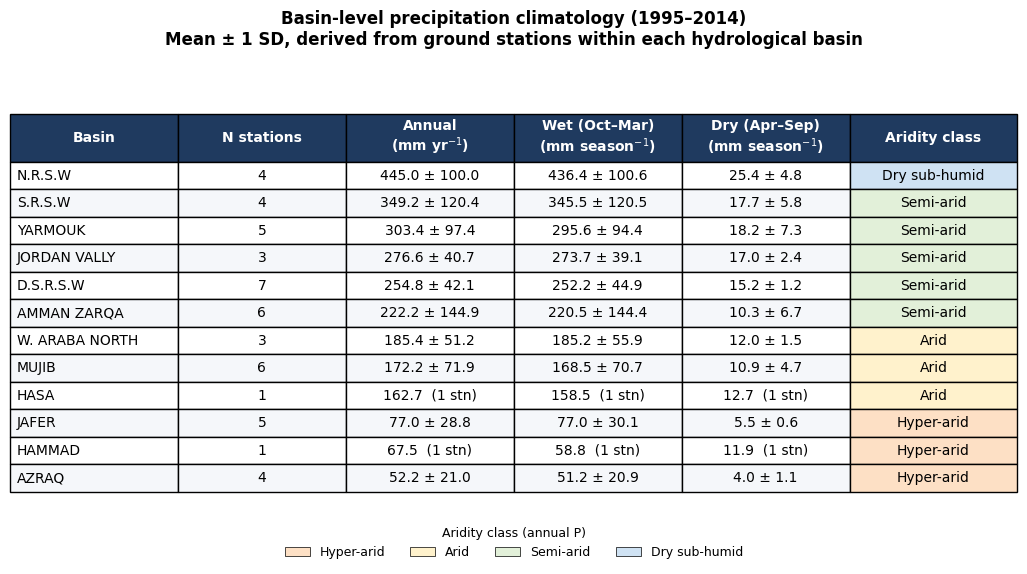

Wrote: C:\Users\ASUS\Desktop\new.work.for.rainfall\comments\Table_Basin_Climatology_1995_2014.png


In [8]:
# Color-coding for the aridity column
ARIDITY_COLORS = {
    "Hyper-arid":    "#fde0c5",  # very pale orange
    "Arid":          "#fff2cc",  # pale yellow
    "Semi-arid":     "#e2f0d9",  # pale green
    "Dry sub-humid": "#cfe2f3",  # pale blue
    "Humid":         "#9bc7e4",  # blue
}

fig, ax = plt.subplots(figsize=(13, 6.2))
ax.axis("off")

table = ax.table(
    cellText=render.values,
    colLabels=render.columns,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.65)

# Header styling
ncols = len(render.columns)
for j in range(ncols):
    cell = table[(0, j)]
    cell.set_facecolor("#1f3a5f")
    cell.set_text_props(color="white", weight="bold")
    cell.set_height(0.10)

# Body styling: alternate row shading + aridity color in last column
n = len(render)
for i in range(1, n + 1):
    for j in range(ncols):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor("#f5f7fa")
    # Aridity column gets the classification color
    aridity = render.iloc[i - 1]["Aridity class"]
    table[(i, ncols - 1)].set_facecolor(ARIDITY_COLORS.get(aridity, "#ffffff"))

# Left-align basin names
for i in range(1, n + 1):
    table[(i, 0)].get_text().set_ha("left")
    table[(i, 0)].PAD = 0.04

ax.set_title(
    "Basin-level precipitation climatology (1995–2014)\n"
    "Mean ± 1 SD, derived from ground stations within each hydrological basin",
    fontsize=12, weight="bold", pad=14,
)

# Legend for aridity classes (only those that appear)
present = [a for a in ["Hyper-arid", "Arid", "Semi-arid", "Dry sub-humid", "Humid"]
           if a in render["Aridity class"].values]
handles = [Rectangle((0, 0), 1, 1, facecolor=ARIDITY_COLORS[a], edgecolor="black", linewidth=0.5) for a in present]
ax.legend(handles, present, title="Aridity class (annual P)", loc="lower center",
          bbox_to_anchor=(0.5, -0.06), ncol=len(present), frameon=False, fontsize=9, title_fontsize=9)

plt.savefig(OUTPUT_PNG, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Wrote:", OUTPUT_PNG)

## 6. Quick checks

In [9]:
# Verify wet+dry approximately reconciles with annual at the basin scale
check = tab.assign(
    sum_seasonal = tab["Wet-season mean (mm)"] + tab["Dry-season mean (mm)"],
    diff = lambda d: (d["Wet-season mean (mm)"] + d["Dry-season mean (mm)"]) - d["Annual mean (mm/yr)"],
)
check[["Basin", "Annual mean (mm/yr)", "sum_seasonal", "diff"]]

,Basin,Annual mean (mm/yr),sum_seasonal,diff
0,N.R.S.W,445.0,461.8,16.8
1,S.R.S.W,349.2,363.2,14.0
2,YARMOUK,303.4,313.8,10.4
3,JORDAN VALLY,276.6,290.7,14.1
4,D.S.R.S.W,254.8,267.4,12.6
5,AMMAN ZARQA,222.2,230.8,8.6
6,W. ARABA NORTH,185.4,197.2,11.8
7,MUJIB,172.2,179.4,7.2
8,HASA,162.7,171.2,8.5
9,JAFER,77.0,82.5,5.5


In [10]:
# Distribution of basins across aridity classes
tab["Aridity class"].value_counts().reindex(
    ["Hyper-arid", "Arid", "Semi-arid", "Dry sub-humid", "Humid"], fill_value=0
)

Aridity class
Hyper-arid       3
Arid             3
Semi-arid        5
Dry sub-humid    1
Humid            0
Name: count, dtype: int64